<a href="https://colab.research.google.com/github/EMIGRIA/AI-MODEL/blob/main/notebook/AI_MODEL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# STEP 1: Install & Import
# ============================================================
!pip install -q tensorflow pandas numpy scikit-learn category_encoders xgboost joblib matplotlib seaborn

import os, re, json, warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    f1_score, recall_score, precision_score, roc_auc_score,
    roc_curve, precision_recall_curve, mean_absolute_error
)
import category_encoders as ce
import joblib
import tensorflow as tf

np.random.seed(42)
tf.random.set_seed(42)
print(f"TensorFlow: {tf.__version__}")
print(f"GPU: {tf.config.list_physical_devices('GPU')}")
print("STEP 1 complete ✓")

TensorFlow: 2.20.0
GPU: []
STEP 1 complete ✓


In [ ]:
# ============================================================
# STEP 2: Load Dataset
# ============================================================
# Upload fake_job_postings.csv ke Colab file explorer dulu
df_raw = pd.read_csv('fake_job_postings.csv')
print(f"\nShape: {df_raw.shape}")
print(f"Fraud: {df_raw['fraudulent'].sum()} ({df_raw['fraudulent'].mean()*100:.2f}%)")
print("STEP 2 complete ✓")


Shape: (17880, 18)
Fraud: 866 (4.84%)
STEP 2 complete ✓


In [ ]:
# ============================================================
# STEP 3: Preprocessing & Feature Engineering
# ============================================================

# --- Country mapping ---
COUNTRY_MAP = {
    'US':'United States','GB':'United Kingdom','UK':'United Kingdom',
    'DE':'Germany','CA':'Canada','AU':'Australia','IN':'India',
    'NZ':'New Zealand','GR':'Greece','IE':'Ireland','SG':'Singapore',
    'MY':'Malaysia','PH':'Philippines','PK':'Pakistan','NG':'Nigeria',
    'AE':'UAE','SA':'Saudi Arabia','QA':'Qatar','KW':'Kuwait',
    'HK':'Hong Kong','TW':'Taiwan','JP':'Japan','KR':'South Korea',
    'CN':'China','TH':'Thailand','ID':'Indonesia','BD':'Bangladesh',
    'FR':'France','IT':'Italy','ES':'Spain','NL':'Netherlands',
    'SE':'Sweden','BR':'Brazil','MX':'Mexico','ZA':'South Africa',
    'EG':'Egypt','JO':'Jordan','IL':'Israel','TR':'Turkey',
}

def get_country(loc):
    if pd.isna(loc): return 'Unknown'
    code = str(loc).split(',')[0].strip()
    return COUNTRY_MAP.get(code, code if len(code) > 2 else 'Unknown')

def parse_salary(s):
    if pd.isna(s): return np.nan, np.nan
    s = str(s).replace('$','').replace(',','')
    if 'k' in s.lower():
        parts = re.findall(r'([\d.]+)\s*k', s, re.IGNORECASE)
        if len(parts) >= 2: return float(parts[0])*1000, float(parts[1])*1000
    parts = re.findall(r'[\d.]+', s)
    if len(parts) >= 2:
        mn, mx = float(parts[0]), float(parts[1])
        if mn < 500 and mx < 500: mn, mx = mn*2080, mx*2080
        return mn, mx
    return np.nan, np.nan

df = df_raw.copy()

# Parse
df['country'] = df['location'].apply(get_country)
sal = df['salary_range'].apply(parse_salary)
df['salary_min'] = sal.apply(lambda x: x[0])
df['salary_max'] = sal.apply(lambda x: x[1])

# Fill missing
for col in ['company_profile','description','requirements','benefits','title']:
    df[col] = df[col].fillna('')
for col in ['employment_type','industry','required_experience','required_education']:
    df[col] = df[col].fillna('Unknown')
for col in ['telecommuting','has_company_logo','has_questions']:
    df[col] = df[col].fillna(0).astype(int)

# Feature engineering
df['salary_mid'] = (df['salary_min'] + df['salary_max']) / 2
df['salary_spread'] = df['salary_max'] - df['salary_min']
df['has_salary'] = df['salary_min'].notna().astype(int)
df['title_length'] = df['title'].str.len()
df['desc_length'] = df['description'].str.len()
df['req_length'] = df['requirements'].str.len()
df['has_company_profile'] = (df['company_profile'].str.len() > 0).astype(int)
df['has_benefits'] = (df['benefits'].str.len() > 0).astype(int)
df['has_requirements'] = (df['requirements'].str.len() > 10).astype(int)

# Scam keywords (universal)
SCAM_KW = ['no experience required','no experience needed','guaranteed income',
           'earn money fast','work from home','easy money','quick money',
           'unlimited earning','be your own boss','financial freedom',
           'urgent hiring','urgently needed','immediate start','act now',
           'limited slots','apply immediately','no interview']
def scam_score(text):
    if not text: return 0
    t = str(text).lower()
    return sum(1 for kw in SCAM_KW if kw in t)

df['scam_keyword_score'] = df['description'].apply(scam_score) + df['requirements'].apply(scam_score)

print(f"Columns after FE: {df.shape[1]}")
print(f"Scam score - Legit mean: {df[df['fraudulent']==0]['scam_keyword_score'].mean():.3f}")
print(f"Scam score - Fraud mean: {df[df['fraudulent']==1]['scam_keyword_score'].mean():.3f}")
print("STEP 3 complete ✓")

Columns after FE: 31
Scam score - Legit mean: 0.009
Scam score - Fraud mean: 0.124
STEP 3 complete ✓


In [ ]:
# ============================================================
# STEP 4: Train/Test Split & Encoding
# ============================================================

y = df['fraudulent']
X_idx_train, X_idx_test, y_train, y_test = train_test_split(
    df.index, y, test_size=0.2, random_state=42, stratify=y
)

# Target encoding (leakage-free)
te = ce.TargetEncoder(cols=['country','employment_type','industry'], smoothing=1.0)
te.fit(df.loc[X_idx_train, ['country','employment_type','industry']], y_train)
encoded = te.transform(df[['country','employment_type','industry']])
df['country_fraud_rate'] = encoded['country']
df['industry_fraud_rate'] = encoded['industry']
df['emp_type_encoded'] = encoded['employment_type']

# Final features
FEATURES = [
    'has_company_profile', 'has_company_logo', 'has_questions', 'telecommuting',
    'has_salary', 'has_benefits', 'has_requirements',
    'title_length', 'desc_length', 'req_length',
    'salary_mid', 'salary_spread', 'scam_keyword_score',
    'country_fraud_rate', 'industry_fraud_rate', 'emp_type_encoded'
]

X_all = df[FEATURES].fillna(0)
X_train = X_all.loc[X_idx_train].values.astype(np.float32)
X_test = X_all.loc[X_idx_test].values.astype(np.float32)
y_train = y_train.values.astype(np.float32)
y_test = y_test.values.astype(np.float32)

# Scale
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train).astype(np.float32)
X_test = scaler.transform(X_test).astype(np.float32)

print(f"\nFeatures: {len(FEATURES)}")
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Fraud rate: {y_train.mean()*100:.2f}%")
for i, f in enumerate(FEATURES, 1):
    print(f"  {i:2d}. {f}")
print("STEP 4 complete ✓")


Features: 16
Train: (14304, 16), Test: (3576, 16)
Fraud rate: 4.84%
   1. has_company_profile
   2. has_company_logo
   3. has_questions
   4. telecommuting
   5. has_salary
   6. has_benefits
   7. has_requirements
   8. title_length
   9. desc_length
  10. req_length
  11. salary_mid
  12. salary_spread
  13. scam_keyword_score
  14. country_fraud_rate
  15. industry_fraud_rate
  16. emp_type_encoded
STEP 4 complete ✓


In [ ]:
# ============================================================
# STEP 5: Custom Focal Loss (Main Quest M2)
# ============================================================

class FocalLoss(tf.keras.losses.Loss):
    """Custom Focal Loss untuk class imbalance."""
    def __init__(self, gamma=2.0, alpha=0.25, name='focal_loss', **kwargs):
        super().__init__(name=name, **kwargs)
        self.gamma = gamma
        self.alpha = alpha

    def call(self, y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        y_true = tf.cast(y_true, tf.float32)
        alpha_t = y_true * self.alpha + (1.0 - y_true) * (1.0 - self.alpha)
        p_t = y_true * y_pred + (1.0 - y_true) * (1.0 - y_pred)
        focal_weight = alpha_t * tf.pow(1.0 - p_t, self.gamma)
        bce = -(y_true * tf.math.log(y_pred) + (1.0 - y_true) * tf.math.log(1.0 - y_pred))
        return tf.reduce_mean(focal_weight * bce)

    def get_config(self):
        config = super().get_config()
        config.update({'gamma': self.gamma, 'alpha': self.alpha})
        return config

print(f"FocalLoss defined (gamma=2.0, alpha=0.25)")
print("STEP 5 complete ✓")

FocalLoss defined (gamma=2.0, alpha=0.25)
STEP 5 complete ✓


In [ ]:
# ============================================================
# STEP 6: Custom F1 Callback (Main Quest M2 - Bonus)
# ============================================================

class F1ScoreCallback(tf.keras.callbacks.Callback):
    """Monitor F1 per epoch."""
    def __init__(self, validation_data, threshold=0.5):
        super().__init__()
        self.X_val, self.y_val = validation_data
        self.threshold = threshold
        self.best_f1 = 0.0
        self.best_epoch = 0
        self.f1_history = []

    def on_epoch_end(self, epoch, logs=None):
        y_pred = self.model.predict(self.X_val, verbose=0).flatten()
        y_bin = (y_pred > self.threshold).astype(int)
        f1 = f1_score(self.y_val, y_bin, zero_division=0)
        self.f1_history.append(f1)
        if f1 > self.best_f1:
            self.best_f1 = f1
            self.best_epoch = epoch + 1

    def on_train_end(self, logs=None):
        print(f"\n[F1Callback] Best F1: {self.best_f1:.4f} at epoch {self.best_epoch}")

print("F1ScoreCallback defined")
print("STEP 6 complete ✓")

F1ScoreCallback defined
STEP 6 complete ✓


In [ ]:
# ============================================================
# STEP 7: Build MLP (Main Quest M1 - Functional API)
# ============================================================

inputs = tf.keras.Input(shape=(len(FEATURES),), name='input_features')
x = tf.keras.layers.Dense(64, activation='relu', kernel_initializer='he_normal')(inputs)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dropout(0.3)(x)
x = tf.keras.layers.Dense(32, activation='relu', kernel_initializer='he_normal')(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dropout(0.2)(x)
x = tf.keras.layers.Dense(16, activation='relu', kernel_initializer='he_normal')(x)
x = tf.keras.layers.Dropout(0.1)(x)
outputs = tf.keras.layers.Dense(1, activation='sigmoid', name='fraud_output')(x)

model = tf.keras.Model(inputs=inputs, outputs=outputs, name='emigria_mlp')

class_weight = {0: 1.0, 1: float((y_train==0).sum()/(y_train==1).sum())}

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

model.summary()
print(f"\nClass weight: fraud = {class_weight[1]:.1f}x")
print("STEP 7 complete ✓")

Model: "emigria_mlp"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_features (InputLayer)     │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fraud_output (Dense)            │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,097 (16.00 KB)

 Trainable params: 3,905 (15.25 KB)

 Non-trainable params: 192 (768.00 B)


Class weight: fraud = 19.6x
STEP 7 complete ✓


In [ ]:
# ============================================================
# STEP 8: Training (Side Quest S4 - TensorBoard)
# ============================================================

EPOCHS = 300
BATCH_SIZE = 32
LOG_DIR = './logs/emigria_mlp'
BEST_MODEL_PATH = 'model/emigria_mlp_best.keras'
os.makedirs('model', exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)

f1_cb = F1ScoreCallback(validation_data=(X_test, y_test), threshold=0.5)

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_auc', patience=40, mode='max',
        restore_best_weights=True, verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_auc', factor=0.5, patience=15, mode='max',
        min_lr=1e-6, verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        BEST_MODEL_PATH, monitor='val_auc', mode='max',
        save_best_only=True, verbose=0
    ),
    tf.keras.callbacks.TensorBoard(log_dir=LOG_DIR, histogram_freq=1),
    f1_cb
]

print(f"Training: epochs={EPOCHS}, batch={BATCH_SIZE}, patience=40")
print(f"Class weight fraud: {class_weight[1]:.1f}x")
print("-" * 60)

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weight,
    callbacks=callbacks,
    verbose=1
)

print(f"\nBest F1 (threshold=0.5): {f1_cb.best_f1:.4f} at epoch {f1_cb.best_epoch}")
print("STEP 8 complete ✓")

Training: epochs=300, batch=32, patience=40
Class weight fraud: 19.6x
------------------------------------------------------------
Epoch 1/300
447/447 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - accuracy: 0.6932 - auc: 0.7858 - loss: 1.0930 - val_accuracy: 0.8277 - val_auc: 0.9036 - val_loss: 0.4323 - learning_rate: 0.0010
Epoch 2/300
447/447 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7968 - auc: 0.8754 - loss: 0.8473 - val_accuracy: 0.8400 - val_auc: 0.9176 - val_loss: 0.3984 - learning_rate: 0.0010
Epoch 3/300
447/447 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8144 - auc: 0.8861 - loss: 0.8151 - val_accuracy: 0.8459 - val_auc: 0.9228 - val_loss: 0.3757 - learning_rate: 0.0010
Epoch 4/300
447/447 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8254 - auc: 0.9037 - loss: 0.7507 - val_accuracy: 0.8507 - val_auc: 0.9265 - val_loss: 0.3606 - learning_rate: 0.0010
Epoch 5/300
447/447 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8326 - auc: 0.9103 - loss: 0.7263 - val_accuracy: 0.8537 - v


Threshold 0.5:    F1=0.4409, Recall=0.8728
Threshold 0.904: F1=0.6134, Recall=0.5549


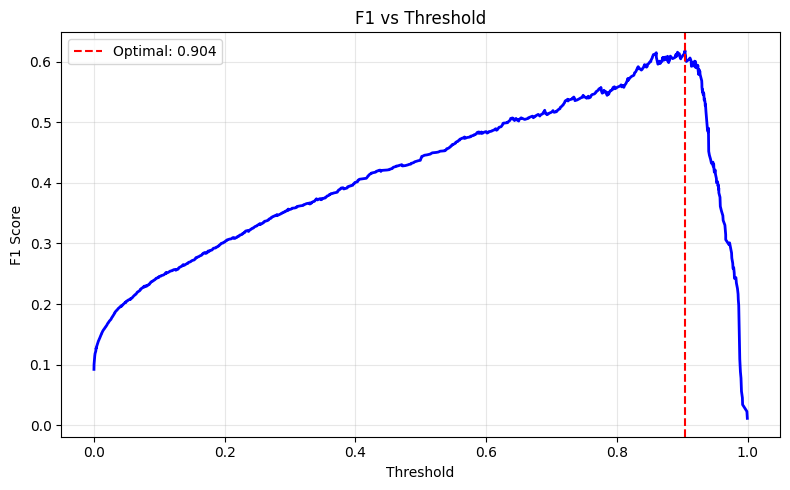

STEP 9 complete ✓


In [ ]:
# ============================================================
# STEP 9: Threshold Optimization
# ============================================================

# Load best model
best_model = tf.keras.models.load_model(BEST_MODEL_PATH)
y_pred_proba = best_model.predict(X_test, verbose=0).flatten()

# Find optimal threshold
prec, rec, thr = precision_recall_curve(y_test, y_pred_proba)
f1s = np.where((prec+rec) > 0, 2*(prec*rec)/(prec+rec), 0)
best_idx = np.argmax(f1s[:-1])
optimal_threshold = float(thr[best_idx])

y_default = (y_pred_proba > 0.5).astype(int)
y_optimal = (y_pred_proba > optimal_threshold).astype(int)

print(f"\nThreshold 0.5:    F1={f1_score(y_test, y_default):.4f}, Recall={recall_score(y_test, y_default):.4f}")
print(f"Threshold {optimal_threshold:.3f}: F1={f1_score(y_test, y_optimal):.4f}, Recall={recall_score(y_test, y_optimal):.4f}")

# Plot
plt.figure(figsize=(8,5))
plt.plot(thr, f1s[:-1], 'b-', linewidth=2)
plt.axvline(x=optimal_threshold, color='r', linestyle='--', label=f'Optimal: {optimal_threshold:.3f}')
plt.xlabel('Threshold'); plt.ylabel('F1 Score')
plt.title('F1 vs Threshold'); plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('threshold_optimization.png', dpi=100); plt.show()
print("STEP 9 complete ✓")


HASIL EVALUASI MLP EMIGRIA
Threshold   : 0.9042
F1 Score    : 61.34%
Recall      : 55.49%
Precision   : 68.57%
AUC-ROC     : 95.14%
Accuracy    : 96.62%
MAE         : 0.1414

Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.98      0.99      0.98      3403
       Fraud       0.69      0.55      0.61       173

    accuracy                           0.97      3576
   macro avg       0.83      0.77      0.80      3576
weighted avg       0.96      0.97      0.96      3576



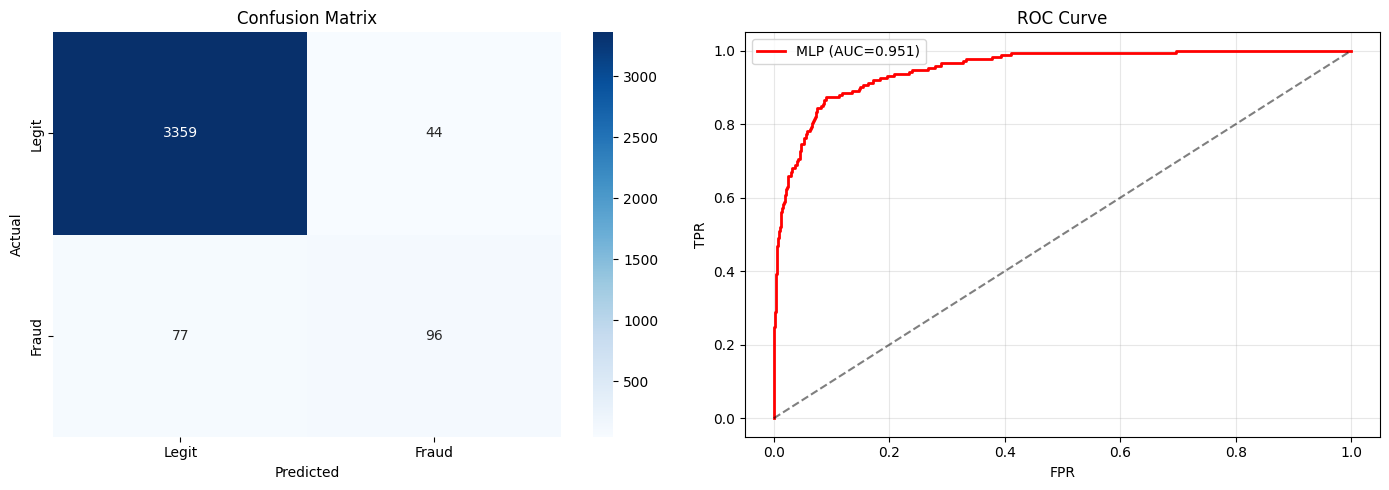

STEP 10 complete ✓


In [ ]:
# ============================================================
# STEP 10: Evaluasi Final
# ============================================================

y_final = (y_pred_proba > optimal_threshold).astype(int)
acc = accuracy_score(y_test, y_final)
f1 = f1_score(y_test, y_final)
recall = recall_score(y_test, y_final)
precision = precision_score(y_test, y_final)
auc = roc_auc_score(y_test, y_pred_proba)
mae = mean_absolute_error(y_test, y_pred_proba)

print(f"\n{'='*50}")
print(f"HASIL EVALUASI MLP EMIGRIA")
print(f"{'='*50}")
print(f"Threshold   : {optimal_threshold:.4f}")
print(f"F1 Score    : {f1*100:.2f}%")
print(f"Recall      : {recall*100:.2f}%")
print(f"Precision   : {precision*100:.2f}%")
print(f"AUC-ROC     : {auc*100:.2f}%")
print(f"Accuracy    : {acc*100:.2f}%")
print(f"MAE         : {mae:.4f}")
print(f"{'='*50}")

print(f"\nClassification Report:")
print(classification_report(y_test, y_final, target_names=['Legitimate', 'Fraud']))

# Plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cm = confusion_matrix(y_test, y_final)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Legit','Fraud'], yticklabels=['Legit','Fraud'])
axes[0].set_title('Confusion Matrix'); axes[0].set_ylabel('Actual'); axes[0].set_xlabel('Predicted')

fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
axes[1].plot(fpr, tpr, 'r-', linewidth=2, label=f'MLP (AUC={auc:.3f})')
axes[1].plot([0,1],[0,1],'k--',alpha=0.5)
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title('ROC Curve'); axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('evaluation_results.png', dpi=100); plt.show()
print("STEP 10 complete ✓")

In [ ]:
# ============================================================
# STEP 11: Export Model & Artifacts (Main Quest M3)
# ============================================================

best_model.save('model/emigria_mlp.keras')
joblib.dump(scaler, 'model/scaler.joblib')
joblib.dump(te, 'model/target_encoder.joblib')

config = {
    "version": "3.0.0",
    "features": FEATURES,
    "optimal_threshold": optimal_threshold,
    "metrics": {"f1": round(f1,4), "recall": round(recall,4),
                "precision": round(precision,4), "auc": round(auc,4),
                "accuracy": round(acc,4), "mae": round(mae,6)},
    "architecture": "Input(16)->64->32->16->1(sigmoid)",
    "loss": "binary_crossentropy + class_weight",
    "custom_components": ["FocalLoss", "F1ScoreCallback"]
}
with open('model/feature_config.json', 'w') as f:
    json.dump(config, f, indent=2)

hist_data = {k: [float(v) for v in vals] for k, vals in history.history.items()}
hist_data['f1_history'] = [float(v) for v in f1_cb.f1_history]
with open('model/training_history.json', 'w') as f:
    json.dump(hist_data, f, indent=2)

print("\nArtifacts saved:")
for f in os.listdir('model'):
    print(f"  model/{f} ({os.path.getsize(f'model/{f}')/1024:.1f} KB)")
print("STEP 11 complete ✓")



Artifacts saved:
  model/.ipynb_checkpoints (4.0 KB)
  model/feature_config.json (0.7 KB)
  model/target_encoder.joblib (18.9 KB)
  model/scaler.joblib (1.0 KB)
  model/emigria_mlp_best.keras (98.3 KB)
  model/training_history.json (15.4 KB)
  model/emigria_mlp.keras (98.0 KB)
STEP 11 complete ✓


STEP 10: Threshold Optimization
Default threshold (0.5):
  F1       : 0.0154
  Recall   : 0.0078
  Precision: 1.0000

Optimal threshold (0.3510):
  F1       : 0.1222
  Recall   : 0.1473
  Precision: 0.1044


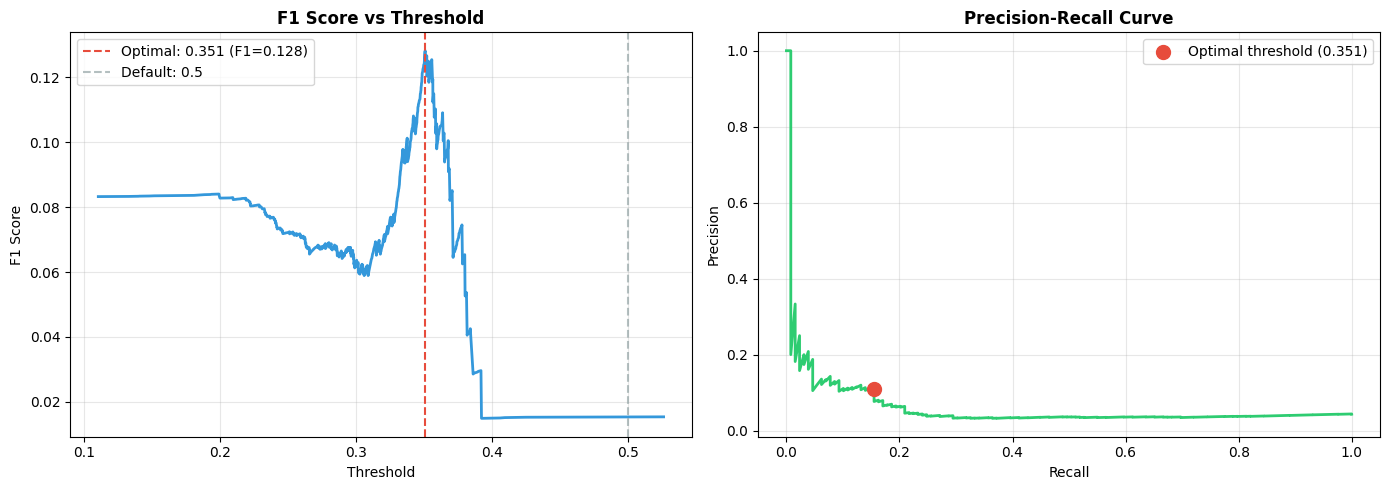


Optimal threshold: 0.3510
Akan digunakan untuk evaluasi final dan inference.

STEP 10 complete ✓


In [ ]:
# ============================================================
# STEP 10: Threshold Optimization
# ============================================================

print("=" * 60)
print("STEP 10: Threshold Optimization")
print("=" * 60)

# Load best model
best_model = tf.keras.models.load_model(
    BEST_MODEL_PATH,
    custom_objects={'FocalLoss': FocalLoss}
)

# Predict probabilities pada test set
y_pred_proba = best_model.predict(X_test_scaled, verbose=0).flatten()

# --- Cari threshold optimal yang maximize F1 ---
precisions, recalls, thresholds = precision_recall_curve(y_test_np, y_pred_proba)
f1_scores = np.where(
    (precisions + recalls) > 0,
    2 * (precisions * recalls) / (precisions + recalls),
    0
)

# Threshold optimal = argmax F1
best_threshold_idx = np.argmax(f1_scores[:-1])  # exclude last (threshold=1.0)
optimal_threshold  = float(thresholds[best_threshold_idx])
optimal_f1         = float(f1_scores[best_threshold_idx])

print(f"Default threshold (0.5):")
y_pred_default = (y_pred_proba > 0.5).astype(int)
print(f"  F1       : {f1_score(y_test_np, y_pred_default):.4f}")
print(f"  Recall   : {recall_score(y_test_np, y_pred_default):.4f}")
print(f"  Precision: {precision_score(y_test_np, y_pred_default):.4f}")

print(f"\nOptimal threshold ({optimal_threshold:.4f}):")
y_pred_optimal = (y_pred_proba > optimal_threshold).astype(int)
print(f"  F1       : {f1_score(y_test_np, y_pred_optimal):.4f}")
print(f"  Recall   : {recall_score(y_test_np, y_pred_optimal):.4f}")
print(f"  Precision: {precision_score(y_test_np, y_pred_optimal):.4f}")

# --- Plot Precision-Recall Curve ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: F1 vs Threshold
axes[0].plot(thresholds, f1_scores[:-1], color='#3498db', linewidth=2)
axes[0].axvline(x=optimal_threshold, color='#e74c3c', linestyle='--',
                label=f'Optimal: {optimal_threshold:.3f} (F1={optimal_f1:.3f})')
axes[0].axvline(x=0.5, color='#95a5a6', linestyle='--', alpha=0.7, label='Default: 0.5')
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('F1 Score')
axes[0].set_title('F1 Score vs Threshold', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Precision-Recall Curve
axes[1].plot(recalls, precisions, color='#2ecc71', linewidth=2)
axes[1].scatter(
    recalls[best_threshold_idx], precisions[best_threshold_idx],
    color='#e74c3c', s=100, zorder=5,
    label=f'Optimal threshold ({optimal_threshold:.3f})'
)
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('threshold_optimization.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"\nOptimal threshold: {optimal_threshold:.4f}")
print(f"Akan digunakan untuk evaluasi final dan inference.")
print("\nSTEP 10 complete ✓")

In [ ]:
# ============================================================
# STEP 12: Inference Demo (Main Quest M4)
# ============================================================

def predict_fraud(features_dict, model, scaler, config):
    """Inference: dict fitur → fraud score."""
    x = np.array([[features_dict.get(f, 0.0) for f in config['features']]], dtype=np.float32)
    x_scaled = scaler.transform(x)
    score = float(model.predict(x_scaled, verbose=0)[0][0])
    threshold = config['optimal_threshold']
    if score >= 0.7: label = "HIGH RISK"
    elif score >= threshold: label = "MEDIUM RISK"
    else: label = "LOW RISK"
    return {"fraud_score": round(score, 4), "fraud_label": label}

# Demo
print("\nInference demo:")
for i in [0, 50, 100]:
    sample = {FEATURES[j]: float(X_test[i][j]) for j in range(len(FEATURES))}
    result = predict_fraud(sample, best_model, scaler, config)
    actual = "FRAUD" if y_test[i] == 1 else "LEGIT"
    print(f"  Sample {i}: {result['fraud_label']} ({result['fraud_score']:.3f}) | Actual: {actual}")

print("\nSTEP 12 complete ✓")
print("\n🎉 SELESAI!")


Inference demo:
  Sample 0: HIGH RISK (0.795) | Actual: LEGIT
  Sample 50: LOW RISK (0.000) | Actual: LEGIT
  Sample 100: LOW RISK (0.000) | Actual: LEGIT

STEP 12 complete ✓

🎉 SELESAI!


TESTTTT